In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

In [25]:
ml_none_results = pd.read_pickle('./ML_preds_none_by_model.pkl')
ml_phys_results = pd.read_pickle('./ML_preds_phys_by_model.pkl')
nn_results = pd.read_pickle('./NN_preds_by_best_model.pkl')
ml_real = pd.read_pickle('./y_test.pkl')

In [28]:
ml_none_results


{'LinearRegression': array([-104.6044949 , -134.79957115, -219.42245439, ...,  362.15858908,
         224.32385927,  316.2915787 ]),
 'Lasso': array([ -48.1787583 , -132.02659403, -213.26623275, ...,  404.72306878,
         267.9222508 ,  351.3599798 ]),
 'Ridge': array([ -69.05952765, -126.80618604, -207.85408585, ...,  394.62545559,
         261.83023435,  350.80306334]),
 'DecisionTree': array([0., 0., 0., ..., 0., 0., 0.]),
 'RandomForest': array([0.        , 0.        , 0.        , ..., 0.10203562, 0.15648855,
        0.1392221 ]),
 'AdaBoost': array([ 6.57156398,  6.57156398,  6.57156398, ..., 77.28232727,
        74.46856369, 74.46856369]),
 'KernelRidgeApprox': array([292.3277787 ,   0.64440915, -60.57885728, ..., 175.59965822,
         85.53231775, -41.87345303]),
 'SVR': array([-229.95203207,  -14.37768229,   -8.53299921, ...,   -6.22335475,
        -134.57169326, -202.81447091]),
 'GaussianProcess': array([-353.62917066,   18.20055057,   -3.75859852, ..., -119.8634837 ,
    

In [181]:
def _is_dt_series(x):
    return isinstance(x, pd.Series) and isinstance(x.index, pd.DatetimeIndex)

def _ensure_series_with_time(y, ref_idx=None, h0=0):
    """
    y: Series(DatetimeIndex) or array-like
    - Series면 그대로 반환
    - array면 ref_idx가 있으면 ref_idx의 '뒤에서 len(y)'만큼 잘라서 인덱스 부여
    - ref_idx가 없으면 h0부터 1시간 간격 가정해 인덱스 생성
    """
    y = y if isinstance(y, pd.Series) else pd.Series(np.asarray(y))
    if _is_dt_series(y):
        return y

    n = len(y)
    if isinstance(ref_idx, pd.DatetimeIndex) and len(ref_idx) >= n:
        idx = ref_idx[-n:]
    else:
        # 시각 정보가 없을 때: h0부터 1시간 간격 가정
        idx = pd.date_range("2000-01-01", periods=n, freq="H") + pd.Timedelta(hours=h0)
    y.index = idx
    return y

def midday_mask(index: pd.DatetimeIndex, hours=(11,12,13,14)):
    return index.hour.isin(hours)

def best_offset(reference_vals: np.ndarray, target_vals: np.ndarray, max_shift=14*24):
    """
    reference_vals 안에서 target_vals(연속 구간)가 가장 잘 맞는 시작점(최소 MSE)을 찾음
    """
    ref, tgt = np.asarray(reference_vals, float), np.asarray(target_vals, float)
    nR, nT = len(ref), len(tgt)
    if nT > nR:
        raise ValueError("target longer than reference")
    lo = max(0, (nR - nT) - max_shift)
    hi = min(nR - nT, max_shift)
    best_s, best_mse = 0, np.inf
    for s in range(lo, nR - nT - hi + 1 + hi):
        mse = np.mean((ref[s:s+nT] - tgt)**2)
        if mse < best_mse:
            best_mse, best_s = mse, s
    return best_s

# === 1) ML 평가: 테스트세트의 11–14시만 ===
def eval_ml_block(ml_real, preds_by_model, hours=(11,12,13,14)):
    y_test_s = _ensure_series_with_time(ml_real)
    test_idx = y_test_s.index
    mask = midday_mask(test_idx, hours=hours)

    rows = []
    for name, y_pred in preds_by_model.items():
        yp = np.asarray(y_pred)
        # 길이 체크
        n = min(len(y_test_s), len(yp))
        yt = y_test_s.iloc[:n].values
        yp = yp[:n]
        idx = test_idx[:n]
        m = midday_mask(idx, hours=hours)

        if m.sum() == 0:
            rows.append((name, 0, np.nan, np.nan, np.nan))
            continue

        yt_m, yp_m = yt[m], yp[m]
        mae  = mean_absolute_error(yt_m, yp_m)
        rmse = np.sqrt(np.mean((yt_m - yp_m)**2))
        r2   = r2_score(yt_m, yp_m) if np.std(yt_m) > 0 else np.nan
        rows.append((name, int(m.sum()), r2, mae, rmse))

    df = pd.DataFrame(rows, columns=["Model","N(11-14h)","R2","MAE","RMSE"])
    return df.sort_values(["MAE","R2"], ascending=[True, False]).reset_index(drop=True)

# === 2) NN 평가: 각 NN의 y_true를 ml_real 타임라인에 정렬 후 11–14시만 ===
def eval_nn_block(nn_results, ml_real, hours=(11,12,13,14)):
    y_ref = ml_real.values
    ref_idx = ml_real.index if isinstance(ml_real, pd.Series) else pd.date_range("2000-01-01", periods=len(y_ref), freq="H")

    rows = []
    for item in nn_results:
        name     = item.get("model", "NN")
        dataset  = item.get("dataset", "unknown")   # ← 구분 라벨 추가
        yt       = np.asarray(item["y_true"])
        yp       = np.asarray(item["y_pred"])

        # ml_real과 alignment (단순히 뒤쪽에 맞춘다고 가정, 필요하면 best_offset 써도 됨)
        s = len(ref_idx) - len(yt)
        idx_slice = ref_idx[s:]
        mask = idx_slice.hour.isin(hours)

        if mask.sum() == 0:
            rows.append((name, dataset, 0, np.nan, np.nan, np.nan))
            continue

        yt_m, yp_m = yt[mask], yp[mask]
        mae  = mean_absolute_error(yt_m, yp_m)
        rmse = np.sqrt(np.mean((yt_m - yp_m)**2))
        r2   = r2_score(yt_m, yp_m) if np.std(yt_m) > 0 else np.nan
        rows.append((name, dataset, int(mask.sum()), r2, mae, rmse))

    df = pd.DataFrame(rows, columns=["NN_Model","Dataset","N(11-14h)","R2","MAE","RMSE"])
    return df.sort_values(["Dataset","MAE"], ascending=[True, False]).reset_index(drop=True)


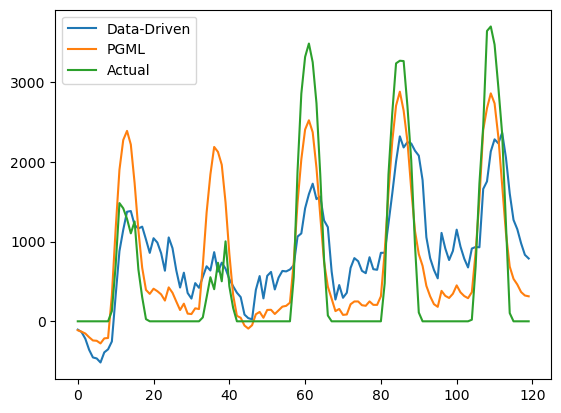

In [182]:
plt.plot(ml_none_results['LinearRegression'][:120], label='Data-Driven')
plt.plot(ml_phys_results['LinearRegression'][:120], label='PGML')
plt.plot(ml_real.values[:120], label = 'Actual')
plt.legend()
plt.show()

In [205]:
# ml_none_eval = eval_ml_block(ml_real, ml_none_results, hours=(12,13,14))
# ml_phys_eval = eval_ml_block(ml_real, ml_phys_results, hours=(12,13,14))
# nn_eval = eval_nn_block(nn_results, ml_real, hours=(12,13,14))

ml_none_eval = eval_ml_block(ml_real, ml_none_results, hours=(11,12,13,14,15))
ml_phys_eval = eval_ml_block(ml_real, ml_phys_results, hours=(11,12,13,14,15))
nn_eval = eval_nn_block(nn_results, ml_real, hours=(11,12,13,14,15))

In [206]:
ml_none_eval

,Model,N(11-14h),R2,MAE,RMSE
0,XGBoost,485,0.579919,493.451397,680.595763
1,RandomForest,485,0.551881,518.554058,702.941691
2,LightGBM,485,0.530852,522.783155,719.246005
3,GaussianProcess,485,0.549832,527.541459,704.546589
4,DecisionTree,485,0.439073,586.181194,786.458848
5,KernelRidgeApprox,485,0.394829,654.178598,816.886735
6,AdaBoost,485,-0.028955,952.520539,1065.174709
7,SVR,485,-0.659041,1127.689308,1352.543295
8,LinearRegression,485,-0.627520,1153.209541,1339.632808
9,Lasso,485,-0.657583,1166.278138,1351.948860


In [207]:
ml_phys_eval

,Model,N(11-14h),R2,MAE,RMSE
0,KernelRidgeApprox,485,0.559291,485.447325,697.105318
1,RandomForest,485,0.561588,498.018179,695.286769
2,SVR,485,0.552129,500.486702,702.747501
3,LightGBM,485,0.546658,504.039374,707.026421
4,XGBoost,485,0.543778,506.260903,709.268405
5,GaussianProcess,485,0.496819,529.694320,744.877175
6,DecisionTree,485,0.405012,566.871420,809.984748
7,Ridge,485,0.310812,750.318655,871.749200
8,LinearRegression,485,0.310924,750.332579,871.678449
9,Lasso,485,0.310523,750.416403,871.931986


In [208]:
nn_eval

,NN_Model,Dataset,N(11-14h),R2,MAE,RMSE
0,DNN,none,485,0.511947,593.224536,733.594585
1,GRU,none,480,0.336600,563.799972,849.764775
2,RNN,none,480,0.409418,544.914863,801.772364
3,CNN,none,485,0.568267,522.678541,689.969776
4,LSTM,none,485,0.551480,508.229864,703.256443
5,RNN,physics,485,0.408694,558.846032,807.474748
6,GRU,physics,485,0.447565,530.084500,780.482487
7,DNN,physics,485,0.570862,524.680602,687.893302
8,CNN,physics,480,0.590118,520.250656,667.944501
9,LSTM,physics,480,0.552169,470.604392,698.181170


In [236]:
# ===== 공통: 모델명 매핑과 순서(이미 있다면 생략) =====
NAME_MAP = {
    "LinearRegression": "Linear", "Lasso": "Lasso", "Ridge": "Ridge",
    "DecisionTree": "DT", "RandomForest": "RF",
    "XGBoost": "XGBoost", "AdaBoost": "AdaBoost", "LightGBM": "LightGBM",
    "KernelRidgeApprox": "KRR", "SVR": "SVR", "GaussianProcess": "GPR",
}
ORDER = ["Linear","Lasso","Ridge","DT","RF","XGBoost",
         "AdaBoost","LightGBM","KRR","SVR","GPR","RNN","GRU","LSTM","CNN","DNN"]

def _clean_name(s): return NAME_MAP.get(s, s)

# ===== 1) 임의 metric(R2/MAE/RMSE) 종합 테이블 =====
def build_combined_metric(ml_none_eval, ml_phys_eval, nn_eval, metric="R2", how_nn="best"):
    """
    metric: 'R2' | 'MAE' | 'RMSE'
    how_nn: 'best' → NN 각 모델에서 metric이 'R2는 최대 / MAE·RMSE는 최소'를 선택
            'mean' → NN을 평균으로 집계
    반환: combined (index=Model, columns=['Data-driven','PGNN'])
    """
    # ML 쪽 (각 모델에서 metric의 '좋은 값'을 선택)
    if metric == "R2":
        ml_none_agg = ml_none_eval.assign(Model=lambda d: d["Model"].map(_clean_name)) \
                                  .groupby("Model", as_index=False)[metric].max()
        ml_phys_agg = ml_phys_eval.assign(Model=lambda d: d["Model"].map(_clean_name)) \
                                  .groupby("Model", as_index=False)[metric].max()
    else:  # MAE, RMSE → 낮을수록 좋음
        ml_none_agg = ml_none_eval.assign(Model=lambda d: d["Model"].map(_clean_name)) \
                                  .groupby("Model", as_index=False)[metric].min()
        ml_phys_agg = ml_phys_eval.assign(Model=lambda d: d["Model"].map(_clean_name)) \
                                  .groupby("Model", as_index=False)[metric].min()

    combined = (ml_none_agg.rename(columns={metric:"Data-driven"})
                           .merge(ml_phys_agg.rename(columns={metric:"PGNN"}),
                                  on="Model", how="outer"))

    nn_tmp = nn_eval.copy()
    nn_tmp["Model"]   = nn_tmp["NN_Model"].map(_clean_name)
    nn_tmp["Dataset"] = nn_tmp["Dataset"].map({"none":"Data-driven","physics":"PGNN"})

    if how_nn == "mean":
        agg = "mean"
    else:
        # 'best': R2는 max, MAE/RMSE는 min
        agg = "max" if metric == "R2" else "min"

    nn_piv = (nn_tmp.groupby(["Model","Dataset"])[metric]
                    .agg(agg).reset_index()
                    .pivot(index="Model", columns="Dataset", values=metric)
                    .reset_index())

    # ML + NN 병합, 같은 열이 둘 다 있으면 '더 좋은 값' 선택
    combined = combined.merge(nn_piv, on="Model", how="outer", suffixes=("","_NN"))

    def _better(a, b):
        if a is None: return b
        if b is None: return a
        if metric == "R2":
            return np.nanmax([a, b], axis=0)
        else:
            return np.nanmin([a, b], axis=0)

    for col in ["Data-driven","PGNN"]:
        if col+"_NN" in combined:
            a = combined[col].values
            b = combined[col+"_NN"].values
            combined[col] = _better(a, b)
            combined.drop(columns=[col+"_NN"], inplace=True)

    # 표시 순서
    combined["order"] = combined["Model"].map({n:i for i,n in enumerate(ORDER)})
    combined.sort_values(["order","Model"], inplace=True)
    combined = combined.drop(columns=["order"]).set_index("Model")
    return combined

# ===== 2) 막대 그래프 (metric별 공용) =====
def plot_grouped_metric(combined, metric="R2", ylim=None):
    models = combined.index.tolist()
    v_none = combined["Data-driven"].values
    v_phys = combined["PGNN"].values

    x = np.arange(len(models)); w = 0.38
    fig, ax = plt.subplots(figsize=(16,6))
    b1 = ax.bar(x - w/2, v_none, width=w, label="Data-driven", hatch='//')
    b2 = ax.bar(x + w/2, v_phys, width=w, label="PGML")

    def annotate(bars):
        for bar in bars:
            h = bar.get_height()
            if np.isfinite(h):
                if metric == "R2":
                    label = f"{h:.2f}"
                    offset = 0.01
                else:  # MAE, RMSE
                    label = f"{h:.0f}"
                    offset = max(3, h*0.0005)  # 값 크기에 따라 조금 띄우기
                ax.text(bar.get_x()+bar.get_width()/2, h + offset,
                        label, ha="center", va="bottom", fontsize=9)

    annotate(b1); annotate(b2)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=0, ha="center")
    ax.set_ylabel(metric, fontsize = 12)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(); ax.grid(axis='y', alpha=.25)
    plt.tight_layout(); plt.show()



In [237]:
combined_r2  = build_combined_metric(ml_none_eval, ml_phys_eval, nn_eval, metric="R2",  how_nn="best")

combined_mae = build_combined_metric(ml_none_eval, ml_phys_eval, nn_eval, metric="MAE", how_nn="best")

combined_rmse = build_combined_metric(ml_none_eval, ml_phys_eval, nn_eval, metric="RMSE", how_nn="best")

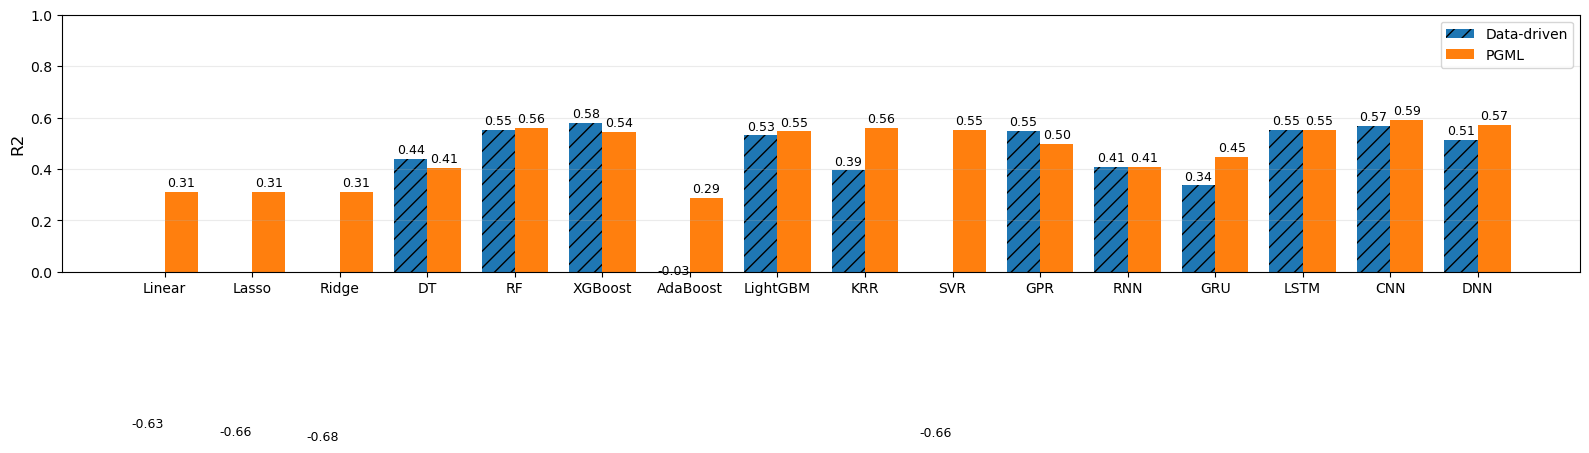

In [238]:
plot_grouped_metric(combined_r2, metric="R2", ylim=(0.0, 1.0))

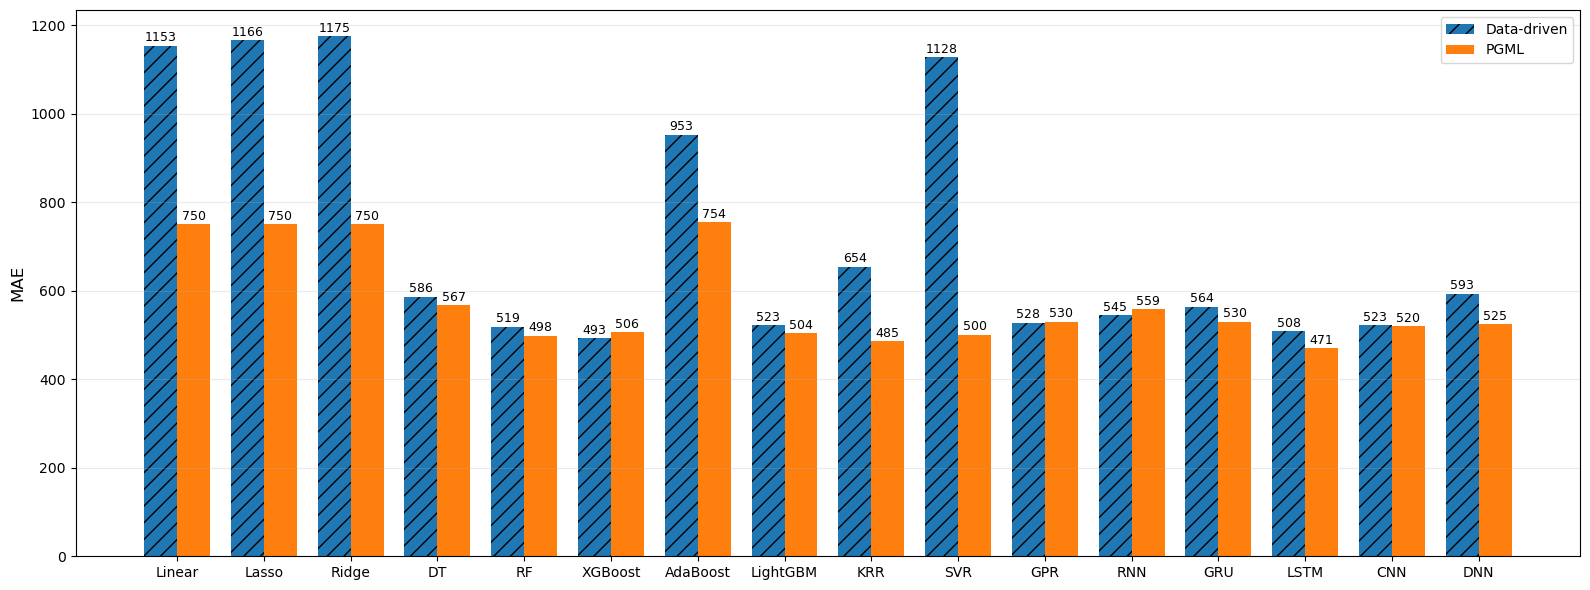

In [239]:
plot_grouped_metric(combined_mae, metric="MAE") 

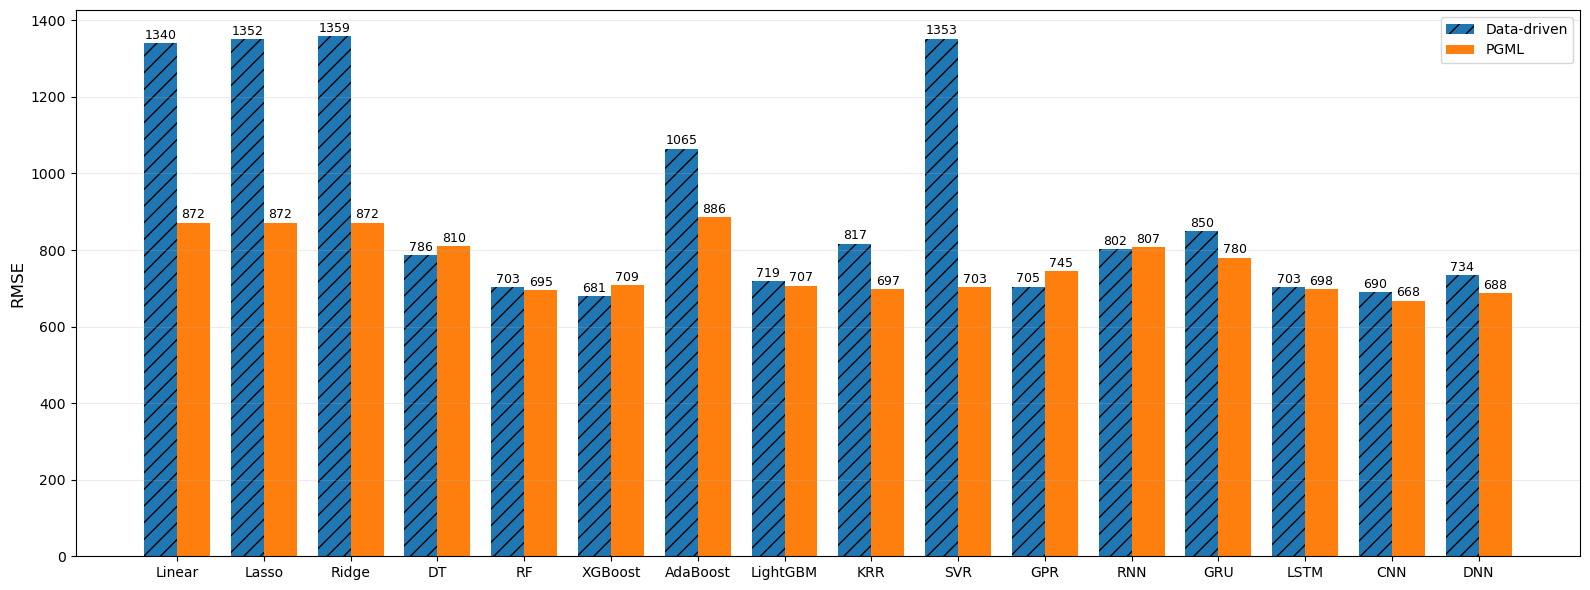

In [240]:
plot_grouped_metric(combined_rmse, metric="RMSE")

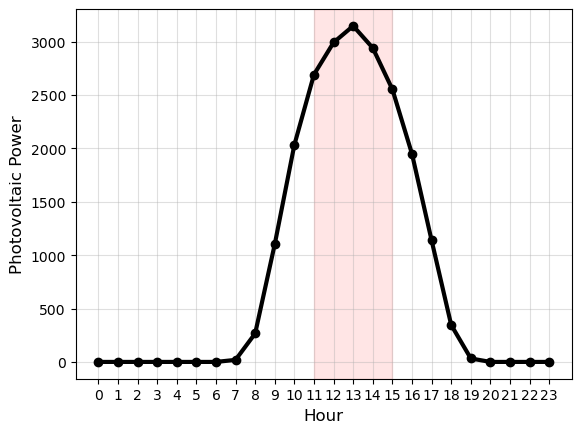

In [249]:
plt.plot(ml_real.groupby(ml_real.index.hour).mean(), color = 'black', lw = 3, marker = 'o')
plt.xticks(range(0,24))
plt.grid(alpha = 0.4)
# for i in [11, 12, 13, 14, 15]:
#     plt.axvline(i, color = 'red', ls = '--', alpha = 0.5)
plt.axvspan(11, 15, color = 'red', alpha = 0.1)
plt.xlabel('Hour', fontsize = 12)
plt.ylabel('Photovoltaic Power', fontsize = 12)
plt.show()